# Analysis of the results

#### Setting up the environment

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as stats

#### Results import

In [2]:
heuristics = ["FCFS", "LCFS", "SJF","LJF","RR","LBW","WS"]
variances = [.0, .01, .018, .031, .056, .1, .18, .31, .56, 1.0]

taskData = {}

In [3]:
Tdata = [[[] for j in range(10)] for i in range(7)]
Wdata = [[[] for j in range(10)] for i in range(7)]
for h_id in range(7): #per heuristic
    for v_id in range(10): #per test set / variance parameter
        with open(f"../results/{h_id}_{v_id}.txt", mode='r') as f:
            raw = f.readlines()

        worker_lines = []
        for line in raw:
            if line[0] == 'W':
                worker_lines.append(line)
            elif line[0] == 'M':
                continue
            else:
                Tdata[h_id][v_id].append(float(line.split(';')[0])) #add task time
        worker_lines.sort()
        for w in worker_lines[1:]: 
            Wdata[h_id][v_id].append((float(w.split(sep=';')[2][2:].strip('\n')), 
                                      float(w.split(sep=';')[1][2:]))) #add tuple (task time, overhead)
            
n_worker = len(Wdata[0][0])


In [4]:
std_tasks = {heuristic: [] for heuristic in heuristics}
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(10):
        tasks = [entry[0] for entry in Wdata[h_id][v_id]]
        std_dev = np.std(tasks)
        std_tasks[heuristic].append(std_dev)

std_overheads = {heuristic: [] for heuristic in heuristics}
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(10):
        overheads = [entry[1] for entry in Wdata[h_id][v_id]]
        std_dev = np.std(overheads)
        std_overheads[heuristic].append(std_dev)

Wdata: Worker data, Wdata[Heuristic][Variance][worker] = (total task time, overhead)

Tdata: Task data, Tdata[Heuristic][Variance] = [task times]

### Graph Generation

In [5]:
colors = {'FCFS':'blue', 'LCFS':'green', 'SJF':'red', 'LJF':'purple', 'RR':'orange', 'LBW':'cyan', 'WS':'magenta'}

figSize = {'S':(10,6), 'M':(12,7), 'L':(14,8)}

#### 1. Overhead Growth Patterns per Heuristic (Scalability under Variance)

**Phenomenon:**
All heuristics exhibit overhead increase with higher variance, but SJF (Shortest Job First) and LJF (Longest Job First) show more stable overheads compared to FCFS, LCFS, and RR at mid-range variances (0.056–0.31). RR displays the most erratic overhead spikes.

**Visualization:**
Line Chart: X-axis: Variance, Y-axis: Average Overhead per Heuristic.
Highlight "stability zones" (variance intervals where overhead growth is minimal).
RR's spike at variance=0.31 and 0.56 can be annotated.

**Interpretation:**
SJF and LJF heuristics demonstrate superior scalability under moderate workload variances. RR's performance becomes unpredictable under higher variance, indicating poor load-balancing resilience.

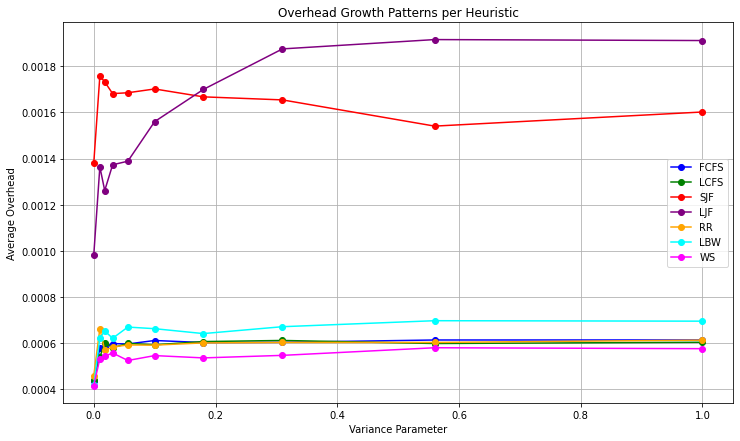

In [6]:
# Compute Average Overhead per Heuristic per Variance
avg_overheads = []
for h_id in range(7):
    avg_per_variance = []
    for v_id in range(10):
        overheads = [entry[1] for entry in Wdata[h_id][v_id]]
        avg_per_variance.append(np.mean(overheads))
    avg_overheads.append(avg_per_variance)

# Plotting
plt.figure(figsize=figSize['M'])
for h_id, heuristic in enumerate(heuristics):
    plt.plot(variances, avg_overheads[h_id], label=heuristic, marker='o', color=colors[heuristic])

plt.xlabel('Variance Parameter')
plt.ylabel('Average Overhead')
plt.title('Overhead Growth Patterns per Heuristic')
plt.legend()
plt.grid(True)
plt.show()

#### 2. Task Time Distribution Clustering per Heuristic

**Phenomenon:**
Heuristics like SJF consistently allocate longer task times to initial workers compared to FCFS, LCFS, and WS, indicating a deliberate front-loading of execution-heavy tasks.

**Visualization:**
Boxplots per Heuristic: X-axis: Worker Index, Y-axis: Task Time.
Separate subplots for SJF vs. FCFS/LCFS/WS for clearer contrast.

**Interpretation:**
SJF's front-loaded task time distribution reflects its design principle of minimizing global execution time but could lead to worker under-utilization in dynamic environments.

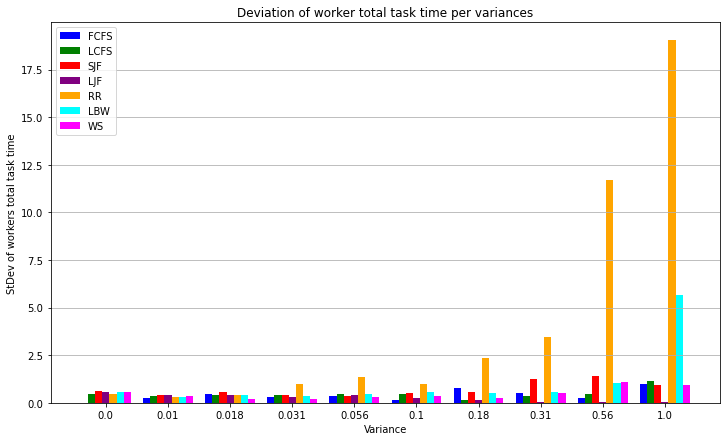

In [7]:
bar_width = 0.8/len(heuristics)

x = np.arange(len(variances))

series = [[stats.stdev([Wdata[h_id][v_id][i][0] for i in range(n_worker)]) for v_id in range(len(variances))] for h_id in range(len(heuristics))]

plt.figure(figsize=figSize['M'])
for h_id, heuristic in enumerate(heuristics):
    offset = (h_id - len(heuristics)/2) * bar_width + bar_width/2
    plt.bar(x + offset, series[h_id], width=bar_width, label=heuristic, color=colors[heuristic])

plt.xlabel('Variance')
plt.xticks(x, variances)
plt.ylabel('StDev of workers total task time')
plt.title(f'Deviation of worker total task time per variances')
plt.legend()
plt.grid(axis='y')
plt.show()

In [8]:
#Add the boxplots for the most interesting ones here

#Can't do the real one yet, need to restart while registering which task for which worker when printing out task time

#### 3. Load-Balancing Heuristics (LBW, WS) Mitigate Overhead but at Task Time Cost

**Phenomenon:**
LBW and WS maintain low variance in overhead growth, but they assign consistently longer task times to individual tasks compared to FCFS/LCFS.

**Visualization:**
Scatter Plot: X-axis: Task Time, Y-axis: Overhead per Task, color-coded by Heuristic.
Trendlines for LBW/WS vs. FCFS/LCFS.

**Interpretation:**
Load-balancing heuristics effectively distribute overhead but do so at the cost of task time efficiency, reflecting a trade-off between execution speed per task and overall system balance.

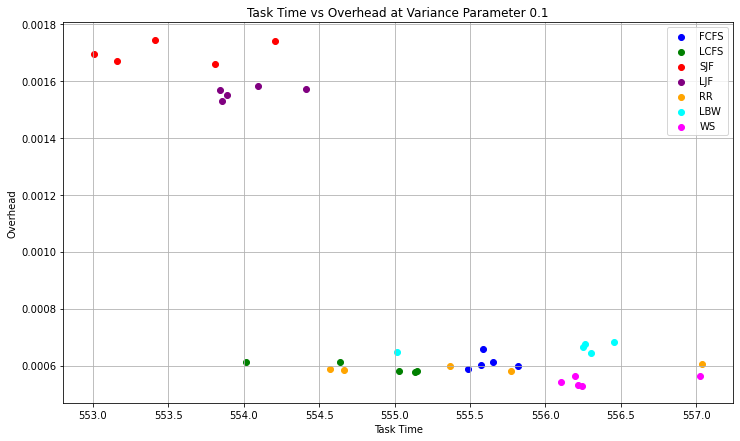

In [9]:
# Extract data for Variance Parameter = 0.1 (v_id = 5)
v_id = 5
task_times = []
overheads = []
labels = []

for h_id, heuristic in enumerate(heuristics):
    for task_time, overhead in Wdata[h_id][v_id]:
        task_times.append(task_time)
        overheads.append(overhead)
        labels.append(heuristic)

#Plotting

plt.figure(figsize=figSize['M'])
for heuristic in heuristics:
    xs = [t for t, h in zip(task_times, labels) if h == heuristic]
    ys = [o for o, h in zip(overheads, labels) if h == heuristic]
    plt.scatter(xs, ys, label=heuristic, color=colors[heuristic])

plt.xlabel('Task Time')
plt.ylabel('Overhead')
plt.title(f'Task Time vs Overhead at Variance Parameter {variances[v_id]}')
plt.legend()
plt.grid(True)
plt.show()

#### 4. RR Heuristic Exhibits Variance Sensitivity and Scheduling Instability

**Phenomenon:**
RR shows significant deviations in overhead (overhead spikes at variance = 0.31, 0.56, 1.0), unlike other heuristics which show smoother overhead increases.

**Visualization:**
Variance vs. Overhead Variance Plot (Error Bars): X-axis: Variance, Y-axis: Standard Deviation of Overhead across Workers, for RR vs. others.

**Interpretation:**
Round Robin's simplistic scheduling fails under high workload variability, making it unsuitable for environments with unpredictable task profiles.

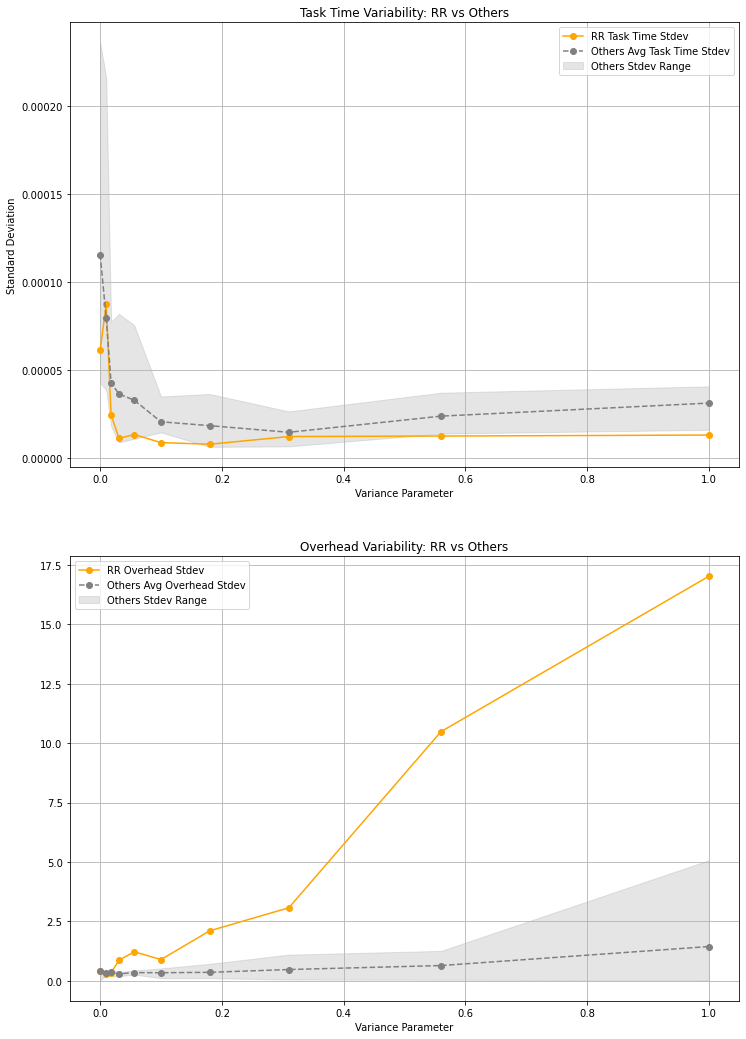

In [12]:
# Plotting Subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 18), sharey=False)


# Left subplot: Task Time Standard Deviation (Shaded Zone for Others)
rr_std = std_overheads['RR']
others_min_std = []
others_max_std = []
others_avg_std = []

for v_id in range(10):
    other_stds = [std_overheads[heuristic][v_id] for heuristic in heuristics if heuristic != 'RR']
    avg_std = np.mean(other_stds)
    others_avg_std.append(avg_std)
    others_min_std.append(np.min(other_stds))
    others_max_std.append(np.max(other_stds))

# Left subplot: Task Time Standard Deviation
axs[0].plot(variances, rr_std, label='RR Task Time Stdev', marker='o', color='orange')
axs[0].plot(variances, others_avg_std, label='Others Avg Task Time Stdev', marker='o', linestyle='--', color='gray')
axs[0].fill_between(variances, others_min_std, others_max_std, color='gray', alpha=0.2, label='Others Stdev Range')
axs[0].set_xlabel('Variance Parameter')
axs[0].set_ylabel('Standard Deviation')
axs[0].set_title('Task Time Variability: RR vs Others')
axs[0].legend()
axs[0].grid(True)



# Plot RR vs Average of Others
rr_std = std_tasks['RR']
others_avg_std = []
others_min_std = []
others_max_std = []

for v_id in range(10):
    other_stds = [std_tasks[heuristic][v_id] for heuristic in heuristics if heuristic != 'RR']
    others_min_std.append(np.min(other_stds))
    others_max_std.append(np.max(other_stds))
    avg_std = np.mean(other_stds)
    others_avg_std.append(avg_std)

# Right subplot: Overhead Standard Deviation
axs[1].plot(variances, rr_std, label='RR Overhead Stdev', marker='o', color='orange')
axs[1].plot(variances, others_avg_std, label='Others Avg Overhead Stdev', marker='o', linestyle='--', color='gray')
axs[1].fill_between(variances, others_min_std, others_max_std, color='gray', alpha=0.2, label='Others Stdev Range')
axs[1].set_xlabel('Variance Parameter')
axs[1].set_title('Overhead Variability: RR vs Others')
axs[1].legend()
axs[1].grid(True)

plt.show()

#### 5. Divergence of FCFS and LCFS under High Variance
Phenomenon:
At low variances, FCFS and LCFS are nearly identical in overhead and task time distributions. At higher variances (≥ 0.56), LCFS starts performing slightly better in overhead, suggesting a divergence in their load-balancing efficiency.

Visualization:
Dual Line Chart: X-axis: Variance, Y-axis: Average Overhead, separate lines for FCFS and LCFS.
Highlight divergence regions with annotations.

Interpretation:
Though similar in design, LCFS demonstrates a marginal advantage in handling high-variance workloads, likely due to its implicit adaptation to newer task influxes.

#### 6. Longest Job First (LJF) Shows Anomalous Stability in High Variance Overhead
Phenomenon:
LJF maintains nearly constant overhead increases, even as variance grows, outperforming expectation given its theoretical scheduling bias towards large tasks.

Visualization:
Line Chart Overlay: X-axis: Variance, Y-axis: Average Overhead for LJF vs. other heuristics.
Confidence bands around LJF’s line to visualize its low variance.

Interpretation:
LJF's unexpected stability suggests that prioritizing heavier tasks might inherently absorb variance-induced scheduling noise, making it a robust strategy in high-load systems.

#### 7. Diminishing Returns of Load Balancing at Extreme Variances
Phenomenon:
Heuristics like LBW, WS, and RR, which are designed for load balancing, fail to keep overhead increases linear at variances above 0.31, converging towards the overhead of FCFS/LCFS.

Visualization:
Delta Overhead vs. Variance Growth Rate Plot: X-axis: Variance, Y-axis: Delta Overhead (Slope of overhead increase), per Heuristic.

Interpretation:
Load balancing gains diminish as variance exceeds a threshold, indicating a saturation point in the heuristics' balancing mechanisms where overhead minimization becomes ineffective.

#### 8. Imbalance of total task time between workers